In [ ]:
import numpy as np
from enum import Enum
import math

class Modulation(Enum):
    BPSK = 1
    QPSK = 2
    QAM8 = 3
    QAM16 = 4

def get_eligible_modulation(reach):
    if reach > 2500:
        return [Modulation.BPSK]
    elif reach > 1250:
        return [Modulation.BPSK, Modulation.QPSK]
    elif reach > 625:
        return [Modulation.BPSK, Modulation.QPSK, Modulation.QAM8]
    else:
        return [Modulation.BPSK, Modulation.QPSK, Modulation.QAM8, Modulation.QAM16]
    
data_rate = 100
reach = 500
modulations = get_eligible_modulation(reach)
num_slots = [int(math.ceil(data_rate/(modulation.value * 12.5))) + 1 for modulation in modulations]
print(num_slots)
d = zip(modulations, num_slots)
for o in d:
    print(o)
# num_slots = int(np.ceil(data_rate / (modulations * 12.5))) + 1

In [ ]:
import numpy as np

alpha_dB: float = 0.2
L_span: float = 80.0
NF_dB: float = 5.0
G_dB = alpha_dB * L_span
G_lin = 10**(G_dB / 10)
NF_lin = 10**(NF_dB / 10)
n_sp = (NF_lin / 2) * (G_lin / (G_lin - 1))
alpha = alpha_dB * (np.log(10) / 10)
al = 10**(alpha_dB/10)
G_l = np.e**(alpha*L_span)
print(n_sp)
print(alpha, G_lin, G_l)

In [ ]:
from data.utility import read_network_file

filepath = "data/nsf/network.txt"
# def generate_request_set(filepath):
nodedf, adjacent = read_network_file(filepath)

[0.8017837257372732, 0.4008918628686366, 0, 0, 0, 0, 0.8017837257372732, 0.5345224838248488, 0.2672612419124244, 0, 0, 0.8017837257372732, 0.6013377943029549, 0.4008918628686366, 0.2004459314343183, 0, 0]


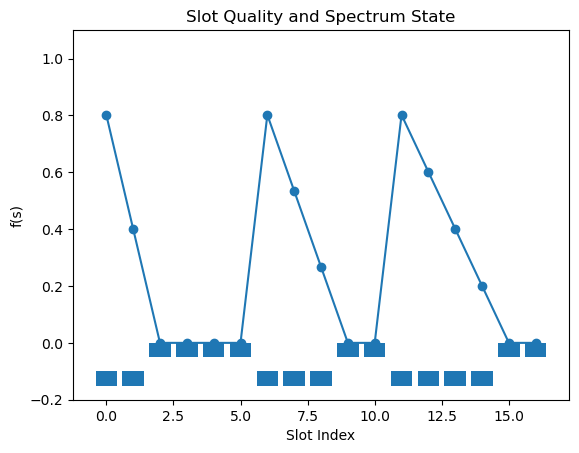

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math

def F(slot_index, spectrum):
    available_block = []
    n = len(spectrum)
    i = 0
    if spectrum[slot_index] == 1:
        return 0
    
    a, b = 0, 0
    while i < n:
        if spectrum[i] == 0:
            start = i
            while i < n and spectrum[i] == 0:
                i += 1
            available_block.append((start, i - 1))
            if start <= slot_index and slot_index <= i-1:
                a = start
                b = i-1
        else:
            i += 1

    max_slot = max([e - s for s, e in available_block])
    sum_square = sum([(e - s)**2 for s, e in available_block])
    f = (b - slot_index + 1) / (b - a + 1) * max_slot / math.sqrt(sum_square)
    return f
            

spectrum = [0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1]
val = [F(i, spectrum) for i in range(len(spectrum))]
print(val)

fig, ax = plt.subplots()

# plot function values
x = np.arange(len(spectrum))
ax.plot(x, val, marker='o')
ax.set_xlabel("Slot Index")
ax.set_ylabel("f(s)")
ax.set_title("Slot Quality and Spectrum State")

# draw spectrum rectangles
for i, slot in enumerate(spectrum):

    if slot == 1:
        height = -0.05
    else:
        height = -0.15

    rect = plt.Rectangle((i - 0.4, height), 0.8, 0.05)
    ax.add_patch(rect)

ax.set_ylim(-0.2, 1.1)

plt.show()

In [6]:
import torch

ModuleNotFoundError: No module named 'torch'